Cosa affronteremo in quest'ultima lezione:
* Riprendiamo le reti convolutive
    * Un esempio di classificazione e successivo esempio di Trasfer Learning usando VGG16
* ResNet
* Preve introduzione all'autoencoder che vedrete nella teoria per poi introdurre UNet e Image Segmentation

# Convolutional Neural Networks

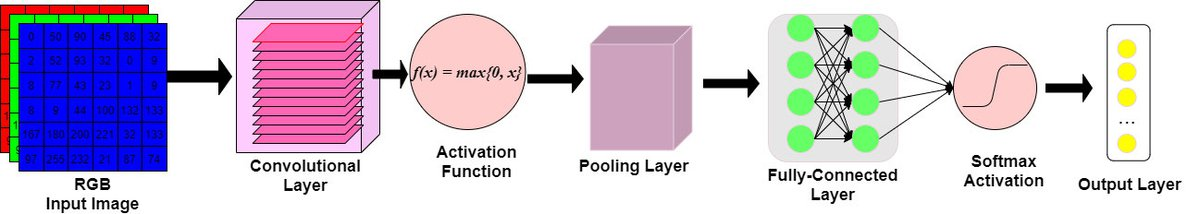


*   Le reti neurali convoluzionali (CNN) sono ampiamente utilizzate nell'ambito del deep learning per il riconoscimento di pattern in immagini.

*   Il layer convoluzionale utilizza un insieme di filtri (o kernel) per eseguire la convoluzione sull'input. Questi filtri sono matrici di pesi che vengono appresi durante l'addestramento del modello.

*  Il filtro scorre sull'input attraverso una finestra (spesso di dimensioni 3x3 o 5x5), eseguendo la moltiplicazione elemento per elemento con i valori corrispondenti nell'input.

*   Dopo la convoluzione, solitamente viene applicata una funzione di attivazione, come la funzione ReLU (Rectified Linear Unit), per introdurre la non linearità nella rete.

*   L'output viene appiattito in un vettore unidimensionale, pronto per essere utilizzato come input per i layer successivi connessi.

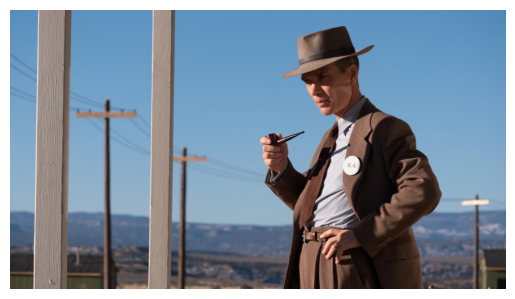

dimensioni dell'immagine: (675, 1200, 3)


In [ ]:
import imageio.v2 as imageio
import matplotlib.pyplot as plt

#Scarichiamo un immagine da un link drive
url="https://drive.google.com/uc?id=1oMwhUwK-tuCaAP-_2aiTyoCrLIcqkDc9"
img = imageio.imread(url) #usiamo un array Numpy per rappresentare l'immagine in RGB

# Visualizza l'immagine con Matplotlib
plt.imshow(img)
plt.axis('off')  # Nasconde gli assi
plt.show()
#Stampiamo alcune caratteristiche dell'immagine.
print(f"dimensioni dell'immagine: {img.shape}")  # (altezza x larghezza x canali)

###Convoluzione
- Conv2D

In [ ]:
from keras.layers import Conv2D

batch_size = 1
height = img.shape[0]
width = img.shape[1]
channels = img.shape[2]

print( f"height = {height}" )
print( f"width = {width}" )
print( f"channels = {channels}" )


input_img =  img.reshape(batch_size, height, width, channels).astype(float) / 255.0


print( f"Img shape: {input_img.shape}")

output = Conv2D(
      filters=1,                    # The number of filters
      kernel_size=(3, 3),           # Height and width of the 2D Convolution window.
      strides=(1, 1),               # (Height,width)
      padding="valid",              # "same" per renderlo della stessa dimensione dell'output
      dilation_rate=(1, 1),         # serve ad allargare il campo visivo del kernel
      groups=1,                     # channels e filtri devono essere divisibili per il numero dei gruppi, gruppi non possono essere piu grandi dei channels

      activation='relu',
      use_bias=True,                # bias pure qui ovviamente
      kernel_initializer="uniform",
      bias_initializer="zeros",
      kernel_regularizer=None,
      bias_regularizer=None,
      activity_regularizer=None,
      kernel_constraint=None,
      bias_constraint=None,

    )(input_img)

print(f"Output shape: {output.shape}")

# Formula su ogni asse.
# ouput = ([input - kernel + (2xpadding)]/stride ) + 1
# 673 = (675 - 3 + 2*0 )/1 + 1
# 1198 = (1200 - 3 + 2*0)/1 + 1

height = 675
width = 1200
channels = 3
Img shape: (1, 675, 1200, 3)
Output shape: (1, 673, 1198, 1)


Attenzione ogni filtro viene applicato su ogni canale e poi i risultati ottenuti vengono sommati. Keras gestisce questa operazione.

### Pooling Layers

1.  MaxPoolingLayer
2.  AveragePoolingLayer

![MaxPooling](https://drive.google.com/uc?id=1jNe2MhWwqbRFyTOhnyRQ61JJVSFbzHL6 )



In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import MaxPooling2D, AveragePooling2D

# Definizione dell'input
input_data = np.array([[[1, 2, 3, 4],
                        [5, 6, 7, 8],
                        [9, 10, 11, 12],
                        [13, 14, 15, 16]]], dtype=np.float32)

# Reshape dell'input per adattarlo al formato richiesto dai modelli
#np.reshape(input_data,(batch_size, height, width, channels))
input_data = np.reshape(input_data, (1, 4, 4, 1))

# Creazione del modello con MaxPooling2D
model_max_pooling = Sequential()
model_max_pooling.add(MaxPooling2D(pool_size=(2, 2)))

# Creazione del modello con AveragePooling2D
model_avg_pooling = Sequential()
model_avg_pooling.add(AveragePooling2D(pool_size=(2, 2)))


# Applicazione dei modelli all'input
output_max_pooling = model_max_pooling.predict(input_data)
output_avg_pooling = model_avg_pooling.predict(input_data)
# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampare i risultati
print("\nRisultato con Max Pooling:")
print(output_max_pooling.squeeze())

print("\nRisultato con Average Pooling:")
print(output_avg_pooling.squeeze())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Input:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Risultato con Max Pooling:
[[ 6.  8.]
 [14. 16.]]

Risultato con Average Pooling:
[[ 3.5  5.5]
 [11.5 13.5]]


### Dropout

Dropout è una tecnica impiegata per prevenire l'overfitting. Quando introduciamo questa regolarizzazione, selezioniamo casualmente i neuroni da ignorare durante l'addestramento. Questo rimuove temporaneamente i contributi all'attivazione dei neuroni e non vengono applicati nemmeno gli aggiornamenti dei pesi che si verificherebbero durante la backpropagation. Ciò migliora la generalizzazione del modello e impedisce che determinati insiemi di pesi si specializzino in caratteristiche specifiche, il che potrebbe portare all'overfitting se non vincolato.

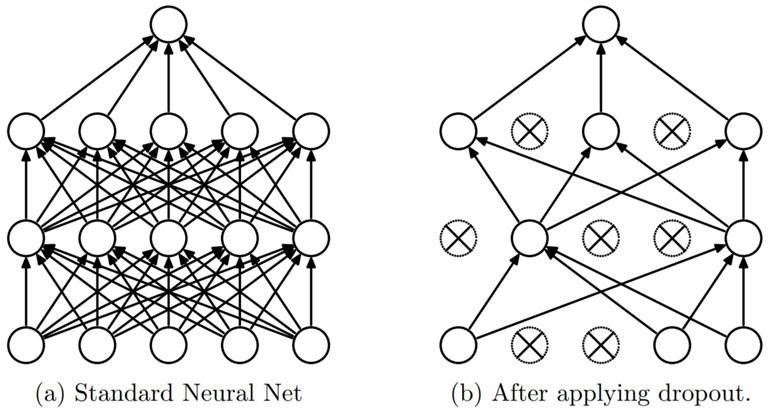

## Esempio implementazione di una CNN in Keras

Download e prepara il dataset

In [1]:
!wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz

--2025-11-26 20:36:30--  http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz [following]
--2025-11-26 20:36:31--  https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4996278331 (4.7G) [application/x-gzip]
Saving to: ‘food-101.tar.gz’

food-101.tar.gz     100%[===================>]   4.65G  20.3MB/s    in 3m 58s  

2025-11-26 20:40:29 (20.0 MB/s) - ‘food-101.tar.gz’ saved [4996278331/4996278331]



In [2]:
!tar xzvf food-101.tar.gz

Output streaming troncato alle ultime 5000 righe.
food-101/images/cannoli/695879.jpg
food-101/images/cannoli/1767088.jpg
food-101/images/cannoli/3201965.jpg
food-101/images/cannoli/3778102.jpg
food-101/images/cannoli/2674065.jpg
food-101/images/cannoli/1169899.jpg
food-101/images/cannoli/1378086.jpg
food-101/images/cannoli/803909.jpg
food-101/images/cannoli/1067240.jpg
food-101/images/cannoli/3002709.jpg
food-101/images/cannoli/2612632.jpg
food-101/images/cannoli/3627612.jpg
food-101/images/cannoli/1798703.jpg
food-101/images/cannoli/560632.jpg
food-101/images/cannoli/512468.jpg
food-101/images/cannoli/2331523.jpg
food-101/images/cannoli/3118302.jpg
food-101/images/cannoli/1499412.jpg
food-101/images/cannoli/1557459.jpg
food-101/images/cannoli/146566.jpg
food-101/images/cannoli/96922.jpg
food-101/images/cannoli/1699562.jpg
food-101/images/cannoli/730051.jpg
food-101/images/cannoli/2177977.jpg
food-101/images/cannoli/2767028.jpg
food-101/images/cannoli/6564.jpg
food-101/images/cannoli/5

In [3]:
import shutil
import json
import os
from pathlib import Path

# 1. Impostiamo il percorso tipico di Colab
root_food_path = Path("/content/food-101")

def split_dataset(root_path):
    """
    Legge i metadati e SPOSTA le immagini in cartelle train/test
    direttamente nell'ambiente Colab.
    """

    # Verifica che il percorso esista prima di iniziare
    if not root_path.exists():
        print(f"Errore: La cartella {root_path} non esiste. Hai estratto il dataset?")
        return

    data_paths = {
        'train': root_path / 'meta/train.json',
        'test': root_path / 'meta/test.json'
    }

    print("Inizio organizzazione dataset (SPOSTAMENTO)...")

    for data_type, meta_path in data_paths.items():
        print(f"Elaborazione set: {data_type}...")

        # Creiamo la cartella principale (es. /content/food-101/train)
        os.makedirs(root_path / data_type, exist_ok=True)

        # Carica il file JSON
        with open(meta_path, 'r') as f:
            food_images = json.load(f)

        # Contatore per monitorare il progresso
        count = 0

        for food_name, image_paths in food_images.items():
            # Crea la sottocartella per il cibo (es. /content/food-101/train/pizza)
            os.makedirs(root_path / data_type / food_name, exist_ok=True)

            for img_path in image_paths:
                # Il JSON contiene stringhe tipo "bibimbap/100284"
                # Aggiungiamo l'estensione .jpg
                file_name = img_path + '.jpg'

                # Percorso Sorgente: /content/food-101/images/classe/img.jpg
                src = root_path / 'images' / file_name

                # Percorso Destinazione: /content/food-101/train/classe/img.jpg
                dst = root_path / data_type / file_name

                # MODIFICA: Usiamo move.
                # Il controllo if src.exists() è fondamentale qui:
                # se rilanci lo script due volte, eviterà errori su file già spostati.
                if src.exists():
                    shutil.move(src, dst)
                    count += 1

        print(f"Completato {data_type}: spostate {count} immagini.")

# Esegui la funzione
split_dataset(root_food_path)
print("Dataset diviso con successo (Spostamento completato)!")

Inizio organizzazione dataset (SPOSTAMENTO)...
Elaborazione set: train...
Completato train: spostate 75750 immagini.
Elaborazione set: test...
Completato test: spostate 25250 immagini.
Dataset diviso con successo (Spostamento completato)!


Fatto per organizzare il dataset così:

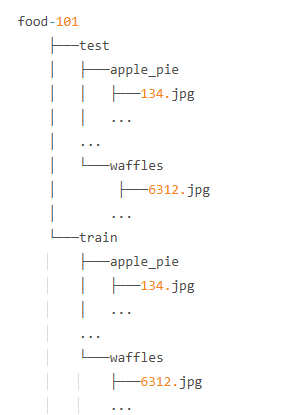

**Normalizziamo e facciamo augmentation**. Con `rescale` ridimensioniamo tutti i valori numerici nelle nostre immagini a un valore compreso tra 0 e 1. ridimensionando i dati dell'immagine si garantisce che tutte le immagini vengano considerate allo stesso modo quando il modello esegue l'addestramento e aggiorna i suoi pesi.

Vogliamo addestrare il nostro algoritmo affinché sia ​​invariante per migliorarne la capacità di generalizzare i dati dell'immagine. Questo può essere fatto introducendo degli **augmentation nelle fasi di pre-elaborazione.** Gli augmentation aumentano la varianza dei dati di addestramento in vari modi, tra cui: rotazione casuale, aumento/diminuzione della luminosità, spostamento della posizione degli oggetti e ribaltamento orizzontale/verticale delle immagini.

Con l'augmentation il nostro algoritmo può riconoscere il cibo da diverse angolazioni, livelli di luminosità o posizioni.

Image Generator di esempio

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Image augmentations
example_generator = ImageDataGenerator(
    rescale=1 / 255.,           # normalize pixel values between 0-1
    vertical_flip=True,         # vertical transposition
    horizontal_flip=True,       # horizontal transposition
    rotation_range=90,          # random rotation at 90 degrees
    height_shift_range=0.3,     # shift the height of the image 30%
    brightness_range=[0.1, 0.9] # specify the range in which to decrease/increase brightness
)

L'augmentation è utile quando si lavora con un piccolo set di dati, poiché aumenta la varianza tra le immagini. Applichiamo l'augmentation solo per l'addestramento. Non applichiamo mai queste trasformazioni durante i test.

In [24]:
train_generator = ImageDataGenerator(
    rescale=1/255.,              # normalize pixel values between 0-1
    brightness_range=[0.1, 0.7], # specify the range in which to decrease/increase brightness
    width_shift_range=0.5,       # shift the width of the image 50%
    rotation_range=90,           # random rotation by 90 degrees
    horizontal_flip=True,        # 180 degree flip horizontally
    vertical_flip=True,          # 180 degree flip vertically
    validation_split=0.15        # 15% of the data will be used for validation at end of each epoch
)

Il nostro set di dati è piuttosto ampio e, sebbene le CNN possano gestire input ad alta dimensionalità come le immagini, l'elaborazione e l'addestramento possono comunque richiedere molto tempo. In questo tutorial, caricheremo solo alcune etichette di classe. La nostra CNN avrà un livello di output di 10 nodi corrispondenti alle prime 10 classi nella directory.

In [25]:
import os
from pathlib import Path

# Usa lo stesso percorso definito nello step precedente
root_food_path = Path("/content/food-101")

# Puntiamo alla cartella 'train' che abbiamo appena popolato
# (è meglio di 'images' perché siamo sicuri che contenga la struttura finale)
target_dir = root_food_path / 'train'

# Ottieni la lista, ma filtriamo per essere sicuri di prendere solo le cartelle
# sorted() le mette in ordine alfabetico
all_classes = sorted([d for d in os.listdir(target_dir) if os.path.isdir(target_dir / d)])

# Prendi le prime 10
class_subset = all_classes[:10]

print(f"Classi selezionate: {class_subset}")

Classi selezionate: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


 `ImageDataGenerator` ci consente di caricare facilmente batch di dati per il training utilizzando il `flow_from_directory`


Una VGG16 per esempio prende in input immagini di 224*224. In questo tutorial, ridimensioneremo le nostre immagini a 128x128. Non troppo piccole da perdere informazioni importanti a causa della bassa risoluzione, ma nemmeno troppo grandi da rallentare le prestazioni della nostra semplice CNN.



In [26]:
# Configurazione base (solo rescaling per ora)


BATCH_SIZE = 32

print(f"Caricamento immagini da: {root_food_path}")

# GENERATORE TRAIN
# Legge dalla cartella /content/food-101/train
traingen = train_generator.flow_from_directory(
    root_food_path / 'train',
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_subset,  # Carica solo le 10 classi selezionate
    shuffle=True,
    seed=42
)

# GENERATORE VALIDATION (o TEST)
# Legge dalla cartella /content/food-101/test
validgen = train_generator.flow_from_directory(
    root_food_path / 'test',
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_subset, # Importante: deve avere le stesse classi del train
    shuffle=False,        # Di solito False per il test set (per valutare in ordine)
    seed=42
)

Caricamento immagini da: /content/food-101
Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


Di seguito è riportata un'architettura relativamente semplice per la nostra prima CNN. Analizziamo alcuni dettagli prima di addestrare il modello:

Avremo quattro "blocchi" convoluzionali composti da (a) strati convoluzionali, (b) uno strato di Max Pooling e (c) una regolarizzazione Dropout.
Ogni strato convoluzionale avrà uno stride  pari a uno (1), l'impostazione predefinita per il Conv2D.
Gli strati di attivazione sono definiti nel Conv2D e utilizzeranno la ReLu.

Tutti i blocchi convoluzionali utilizzeranno una dimensione della finestra del filtro pari a 3x3, ad eccezione del blocco convoluzionale finale, che utilizza una dimensione della finestra pari a 5x5.

Chiamiamo il `Flatten()` all'inizio del livello dense. Questo serve a trasformare le mappe di feature tridimensionali in un tensore di input unidimensionale.

Costruiremo un livello completamente connesso utilizzando livelli Dense.

Poiché si tratta di un problema multi-classe, il nostro livello Fully-Connected ha una funzione di attivazione Softmax.

In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from keras.regularizers import l1_l2

model = Sequential()

#### Input Layer ####
model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same',
                 activation='relu', input_shape=(128, 128, 3)))

#### Convolutional Layers ####
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))  # Pooling
model.add(Dropout(0.2)) # Dropout

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(512, (5,5), padding='same', activation='relu'))
model.add(Conv2D(512, (5,5), activation='relu'))
model.add(MaxPooling2D((4,4)))
model.add(Dropout(0.2))

#### Fully-Connected Layer ####
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(class_subset), activation='softmax'))

model.summary() # a handy way to inspect the architecture

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 512)    │     1,638,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 512)    │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,588,458 (40.39 MB)

 Trainable params: 10,588,458 (40.39 MB)

 Non-trainable params: 0 (0.00 B)

I modelli Keras includono la possibilità di interagire automaticamente con il modello durante l'addestramento. Utilizzeremo alcune tecniche di callback.

* EarlyStopping- monitora le prestazioni del modello e l'interruzione del processo di addestramento previene l'overtraining.
* ModelCheckpoint- salva i pesi migliori per il modello in un file dopo ogni epoca
* PlotLossesKeras- dalla libreria _livelossplot_, mostra grafici di perdita e accuratezza e aggiornamenti dopo ogni epoca

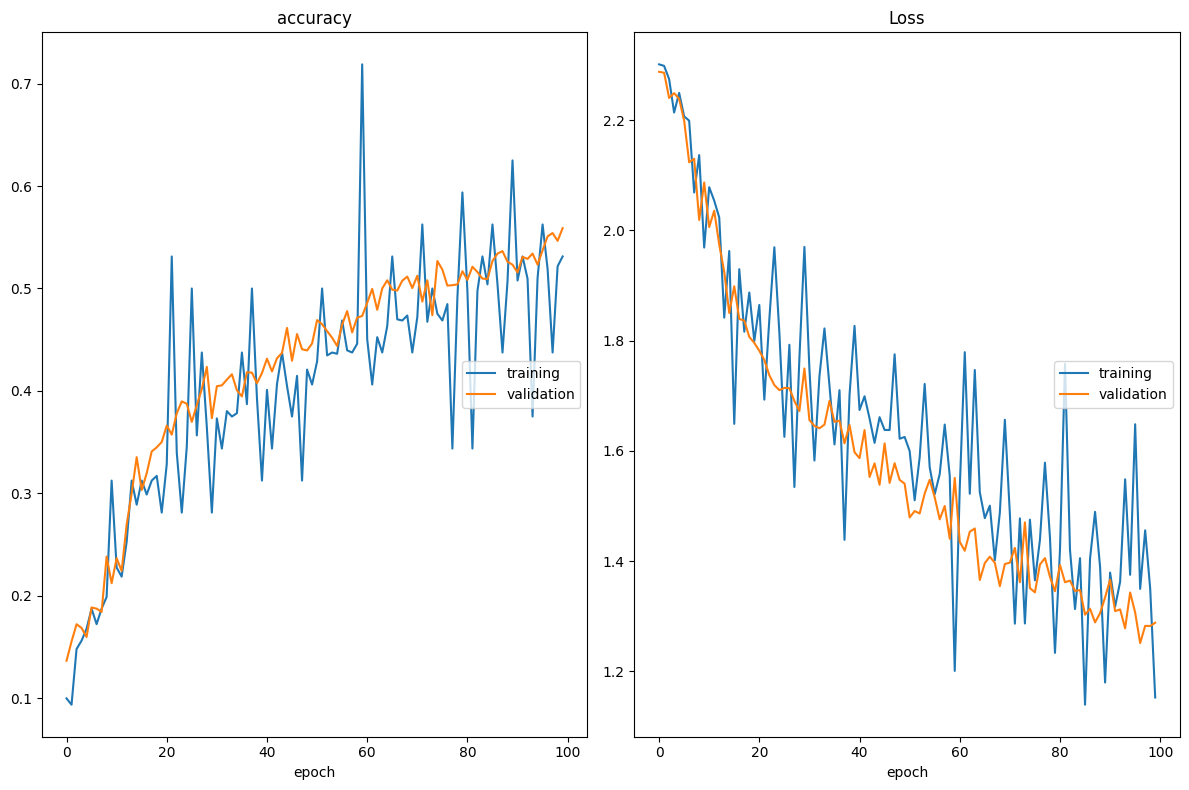

accuracy
	training         	 (min:    0.094, max:    0.719, cur:    0.531)
	validation       	 (min:    0.137, max:    0.559, cur:    0.559)
Loss
	training         	 (min:    1.140, max:    2.301, cur:    1.153)
	validation       	 (min:    1.251, max:    2.288, cur:    1.288)
CPU times: user 1h 12min 14s, sys: 57 s, total: 1h 13min 11s
Wall time: 1h 19min 20s


In [10]:
%%time

from keras.optimizers import RMSprop
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
!pip install livelossplot --quiet

# 2. Importa
from livelossplot import PlotLossesKeras

steps_per_epoch = traingen.samples // BATCH_SIZE
val_steps = validgen.samples // BATCH_SIZE

n_epochs = 100

optimizer = RMSprop(learning_rate=0.0001)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Saves Keras model after each epoch
# Cambia l'estensione in .keras
checkpointer = ModelCheckpoint("img_model.weights.best.keras",
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')

# Early stopping to prevent overtraining and to ensure decreasing validation loss
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

# tensorboard_callback = TensorBoard(log_dir="./logs")

# Actual fitting of the model
history = model.fit(traingen,
                    epochs=n_epochs,
                    steps_per_epoch=steps_per_epoch,
                    validation_data=validgen,
                    validation_steps=val_steps,
                    callbacks=[early_stop, checkpointer, PlotLossesKeras()],
                    verbose=False)

## Evaluating our network
Valuteremo ora la capacità predittiva del modello sui dati di test. Per farlo, è necessario definire un generatore di immagini per i dati di test. Questo generatore non applicherà alcun augmentation delle immagini, poiché si suppone che rappresenti uno scenario reale in cui una nuova immagine viene introdotta nella CNN per la previsione.

In [28]:
test_generator = ImageDataGenerator(rescale=1/255.)

testgen = test_generator.flow_from_directory('/content/food-101/test',
                                             target_size=(128, 128),
                                             batch_size=1,
                                             class_mode=None,
                                             classes=class_subset,
                                             shuffle=False,
                                             seed=42)

Found 2500 images belonging to 10 classes.


Carichiamo i pesi che hanno ottenuto la migliore validation loss durante l'addestramento. Utilizziamo il `predict_class`  del modello, che restituirà il valore di indice dell'etichetta di classe prevista.

Di seguito definiremo alcune funzioni che ci aiuteranno a visualizzare le prestazioni predittive del nostro modello.

`display_results()` confronterà le etichette reali delle immagini con le etichette previste.

`plot_predictions()` ci consentirà di visualizzare un campione delle immagini di prova e le etichette generate dal modello.

In [30]:
import numpy as np # Assicurati di importare numpy

model.load_weights('img_model.weights.best.keras')

# 1. Ottieni le probabilità grezze (es. [0.1, 0.05, 0.85, ...])
predictions = model.predict(testgen)

# 2. Trova l'indice della probabilità più alta per ogni immagine
# Questo fa esattamente quello che faceva predict_classes
predicted_classes = np.argmax(predictions, axis=1)

# Il resto del tuo codice rimane uguale
class_indices = traingen.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())
true_classes = testgen.classes

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def display_results(y_true, y_preds, class_labels):

    results = pd.DataFrame(precision_recall_fscore_support(y_true, y_preds),
                          columns=class_labels).T

    results.rename(columns={0: 'Precision', 1: 'Recall',
                            2: 'F-Score', 3: 'Support'}, inplace=True)

    results.sort_values(by='F-Score', ascending=False, inplace=True)
    global_acc = accuracy_score(y_true, y_preds)

    print("Overall Categorical Accuracy: {:.2f}%".format(global_acc*100))
    return results

def plot_predictions(y_true, y_preds, test_generator, class_indices):

    fig = plt.figure(figsize=(20, 10))
    for i, idx in enumerate(np.random.choice(test_generator.samples, size=20, replace=False)):
        ax = fig.add_subplot(4, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(np.squeeze(test_generator[idx]))
        pred_idx = y_preds[idx]
        true_idx = y_true[idx]

        plt.tight_layout()
        ax.set_title("{}\n({})".format(class_indices[pred_idx], class_indices[true_idx]),
                     color=("green" if pred_idx == true_idx else "red"))

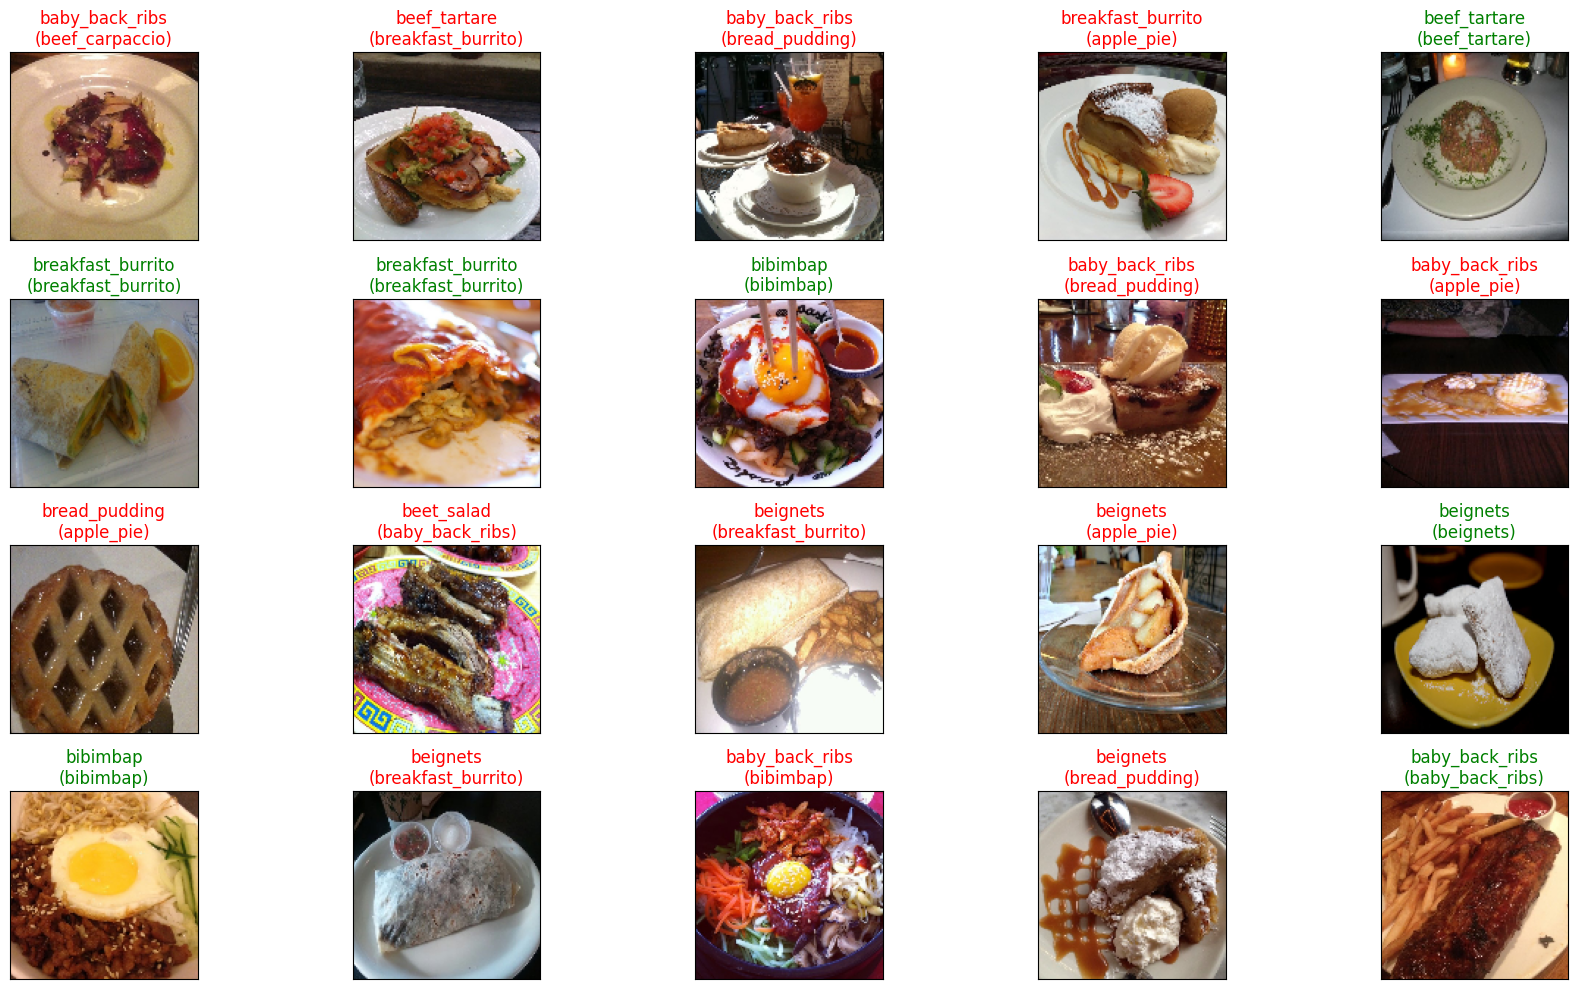

In [32]:
plot_predictions(true_classes, predicted_classes, testgen, class_indices)

In [33]:
display_results(true_classes, predicted_classes, class_indices.values())

Overall Categorical Accuracy: 52.60%


,Precision,Recall,F-Score,Support
beef_carpaccio,0.707865,0.756,0.731141,250.0
bibimbap,0.697872,0.656,0.676289,250.0
beet_salad,0.772973,0.572,0.657471,250.0
beignets,0.450820,0.880,0.596206,250.0
beef_tartare,0.600000,0.528,0.561702,250.0
baby_back_ribs,0.380795,0.920,0.538642,250.0
baklava,0.661017,0.312,0.423913,250.0
breakfast_burrito,0.457447,0.344,0.392694,250.0
apple_pie,0.358621,0.208,0.263291,250.0
bread_pudding,0.420000,0.084,0.140000,250.0


Il nostro modello ha raggiunto un'accuratezza complessiva < 60% , che oscilla a ogni sessione di addestramento. Si tratta di un risultato tutt'altro che elevato, ma per una semplice CNN scritta da zero, è prevedibile!

## Esercizio di Transfer Learning

Una rete neurale convoluzionale quando viene addestrata su un insieme di dati impara prima a rilevare caratteristiche(feature) generiche nelle immagini, come bordi e macchie di colore, e poi a rilevare caratteristiche più complesse.

Nelle applicazioni reali, questo può richiedere giorni di addestramento e milioni di immagini per raggiungere prestazioni elevate. Sarebbe più semplice per noi scaricare un modello generico pre-addestrato e riaddestrarlo sul nostro dataset. Questo è ciò che comporta il Transfer Learning.

In questo senso, il Transfer Learning è un approccio in cui utilizziamo un modello addestrato su un'attività di apprendimento automatico e lo riutilizziamo come punto di partenza per un'attività diversa. Diversi domini di deep learning utilizzano questo approccio, tra cui la classificazione delle immagini, l'elaborazione del linguaggio naturale e persino il gaming! La capacità di adattare un modello addestrato a un'altra attività è incredibilmente preziosa

Possiamo comprendere il Transfer Learning in termini di **Domini** e **Attività** . Nel nostro caso, il dominio è la classificazione delle immagini e il nostro compito è classificare le immagini di alimenti. Partire da zero richiederebbe numerose ottimizzazioni, più dati e un addestramento più lungo per migliorare le prestazioni. Se utilizziamo una CNN già ottimizzata e addestrata per un dominio e un'attività simili, potremmo convertirla in modo che funzioni con la nostra attività. Questo è ciò che il Transfer Learning realizza.


## Utilizzo di livelli convoluzionali preaddestrati
Utilizzando i livelli pre-addestrati , estrarremo le caratteristiche visive dal nostro task/dataset di destinazione .

Utilizzando questi livelli pre-addestrati , possiamo decidere di escludere specifici livelli dall'addestramento. Utilizzeremo i pesi pre-addestrati così come sono, senza aggiornarli con la backpropagation

VGG16 è una rete neurale convoluzionale addestrata su un sottoinsieme del dataset ImageNet , una raccolta di oltre 14 milioni di immagini appartenenti a 22.000 categorie.

 La sua architettura pre-addestrata è in grado di rilevare feature visive generiche presenti nel nostro dataset Food.



# VGG16

La VGG16 è una rete neurale convoluzionale (CNN) presentata nel 2014 da K. Simonyan e A. Zisserman del Visual Geometry Group (da cui il nome VGG) dell'Università di Oxford. È diventata famosa per le sue eccellenti prestazioni nella competizione ImageNet (ILSVRC-2014). La VGG16 è composta principalmente da 13 strati convoluzionali e 3 strati completamente connessi. Usa filtri 3*3

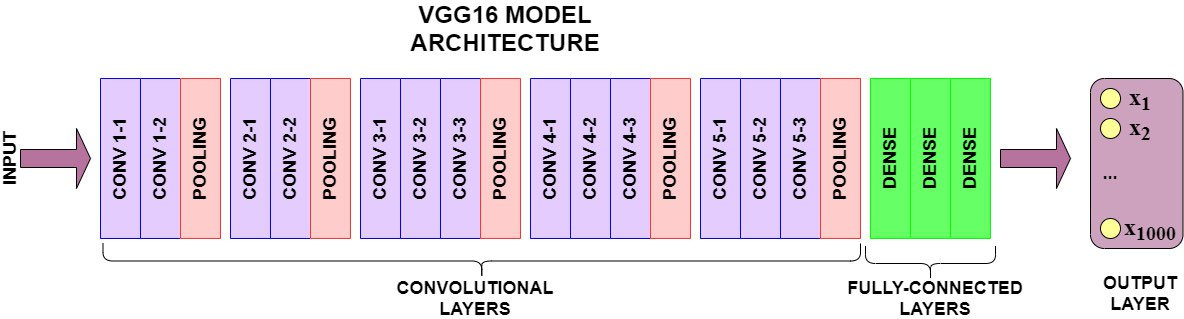

Ora non possiamo utilizzare l'intera architettura del modello pre-addestrato . Il livello Fully-Connected genera 1.000 etichette di output diverse, mentre il dataset che usiamo ha solo due classi per la previsione. Quindi importeremo un modello pre-addestrato come VGG16 , ma "taglieremo" il livello Fully-Connected, chiamato anche modello "top".

In [ ]:
import tensorflow as tf
from tensorflow import keras
import os
from keras.models import Model
from keras.optimizers import Adam
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Dense, Dropout, Flatten
from pathlib import Path
import numpy as np

A differenza delle reti moderne, la VGG16 non divide i pixels per 255. Il metodo `preprocess_input` della rete vgg16 converte l'immagine da RGB a BGR, sottrae a ogni pixel il "valore medio" dei colori del dataset ImageNet originale. I dati risultano "Zero-Centered", il formato matematico esatto su cui la rete è stata addestrata e che i pesi si aspettano.

`validation-split` per lasciare un 15% alla validation

In [ ]:
BATCH_SIZE = 64

train_generator = ImageDataGenerator(rotation_range=90,
                                     brightness_range=[0.1, 0.7],
                                     width_shift_range=0.5,
                                     height_shift_range=0.5,
                                     horizontal_flip=True,
                                     vertical_flip=True,
                                     validation_split=0.15,
                                     preprocessing_function=preprocess_input) # VGG16 preprocessing

test_generator = ImageDataGenerator(preprocessing_function=preprocess_input) # VGG16 preprocessing

In [ ]:
download_dir = Path('/content')


Dividiamo la cartella di training in due flussi separati: usa l'85% delle immagini per l'addestramento vero e proprio e il 15% per la validation.

Carica la cartella di test, senza mischiare le immagini (shuffle=False), per mantenere l'ordine corretto.

Ridimensiona tutto a 224x224 pixel, applicando le distorsioni (augmentation) ai dati di training/validation e lasciando puliti quelli di test.

In [ ]:
train_data_dir = 'food-101/train'
test_data_dir = 'food-101/test'

class_subset = sorted(os.listdir(download_dir/'food-101/images'))[:10] # Using only the first 10 classes

traingen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               classes=class_subset,
                                               subset='training',
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               seed=42)

validgen = train_generator.flow_from_directory(train_data_dir,
                                               target_size=(224, 224),
                                               class_mode='categorical',
                                               classes=class_subset,
                                               subset='validation',
                                               batch_size=BATCH_SIZE,
                                               shuffle=True,
                                               seed=42)

testgen = test_generator.flow_from_directory(test_data_dir,
                                             target_size=(224, 224),
                                             class_mode=None,
                                             classes=class_subset,
                                             batch_size=1,
                                             shuffle=False,
                                             seed=42)

Found 6380 images belonging to 10 classes.
Found 1120 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Usiamo i layers Pre-Trained per feature extraction

1. Scarica il modello pre-addestrato . Assicurati che la parte comprendente i livelli "Fully-Connected", non sia inclusa.
2. I dati dell'immagine vengono passati attraverso i livelli pre-addestrati per estrarre le feature visive convolute. I pesi di questo "corpo" non vengono toccati. Non si riaddestrano. Vengono usati esattamente così come sono.
3. Le nostre immagini vengono passate attraverso i livelli convoluzionali di VGG16, che produrranno un Feature Stack delle feature visive rilevate. Da qui, è facile appiattire il feature stack tridimensionale in un array NumPy, pronto per qualsiasi modellazione si preferisca eseguire

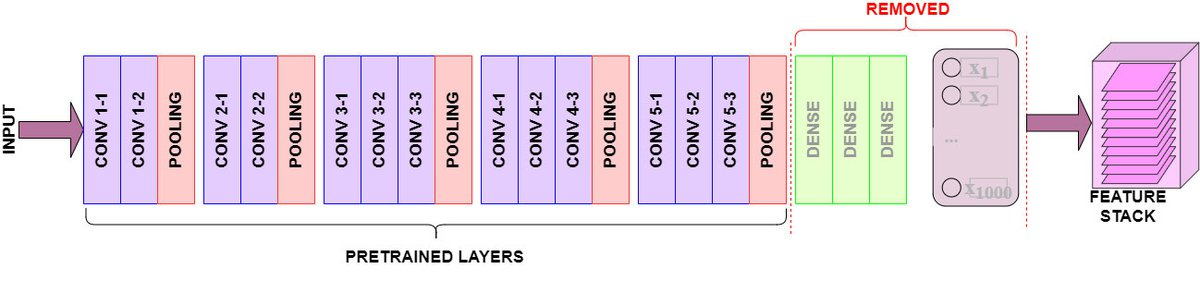

* assegniamo lo stack dei livelli del modello pre-addestrato alla variabile `conv_base`. Si noti che `include_top=False`per escludere il livello completamente connesso pre-addestrato di VGG16.
* se l'argomento fine_tune è impostato su 0, tutti i livelli pre-addestrati verranno congelati e non potranno essere addestrati. In caso contrario, gli ultimi livelli saranno resi disponibili per l'addestramento (questo sarà fatto nell'esempio successivo).
* impostiamo una nuova porzione "superiore" del modello, acquisendo gli conv_base output e appiattendoli.
* definiamo il nuovo livello Fully-Connected, che addestreremo con backpropagation. Includiamo la regolarizzazione dropout per ridurre l'overfitting.
* Infine si definisce il livello di output del modello, in cui il numero totale di output è uguale a n_classes, il numero di classi (10).

In [ ]:
def create_model(input_shape, n_classes, optimizer='rmsprop', fine_tune=0):
    """
    Compiles a model integrated with VGG16 pretrained layers

    input_shape: tuple - the shape of input images (width, height, channels)
    n_classes: int - number of classes for the output layer
    optimizer: string - instantiated optimizer to use for training. Defaults to 'RMSProp'
    fine_tune: int - The number of pre-trained layers to unfreeze.
                If set to 0, all pretrained layers will freeze during training
    """

    # Pretrained convolutional layers are loaded using the Imagenet weights.
    # Include_top is set to False, in order to exclude the model's fully-connected layers.
    conv_base = VGG16(include_top=False,
                     weights='imagenet',
                     input_shape=input_shape)

    # Defines how many layers to freeze during training.
    # Layers in the convolutional base are switched from trainable to non-trainable
    # depending on the size of the fine-tuning parameter.
    if fine_tune > 0:
        for layer in conv_base.layers[:-fine_tune]:
            layer.trainable = False
    else:
        for layer in conv_base.layers:
            layer.trainable = False

    # Create a new 'top' of the model (i.e. fully-connected layers).
    # This is 'bootstrapping' a new top_model onto the pretrained layers.
    top_model = conv_base.output
    top_model = Flatten(name="flatten")(top_model)
    top_model = Dense(4096, activation='relu')(top_model)
    top_model = Dense(1072, activation='relu')(top_model)
    top_model = Dropout(0.2)(top_model)
    output_layer = Dense(n_classes, activation='softmax')(top_model)

    # Group the convolutional base and new fully-connected layers into a Model object.
    model = Model(inputs=conv_base.input, outputs=output_layer)

    # Compiles the model for training.
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

Questo modello eseguirà l'estrazione di feature utilizzando i layer pre-addestrati e addestrerà un layer completamente connesso per le previsioni

In [ ]:
input_shape = (224, 224, 3)
optim_1 = Adam(learning_rate=0.001)
n_classes=10

n_steps = traingen.samples // BATCH_SIZE #passi per finire un'epoca
n_val_steps = validgen.samples // BATCH_SIZE
n_epochs = 50

# First we'll train the model without Fine-tuning
vgg_model = create_model(input_shape, n_classes, optim_1, fine_tune=0)

In [ ]:
!pip install livelossplot --quiet
from livelossplot.inputs.keras import PlotLossesCallback

plot_loss_1 = PlotLossesCallback()

# ModelCheckpoint callback - save best weights
tl_checkpoint_1 = ModelCheckpoint(filepath='tl_model_v1.weights.best.keras',
                                  save_best_only=True,
                                  verbose=1)

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,
                           restore_best_weights=True,
                           mode='min')

Ora possiamo addestrare il modello definito sopra:

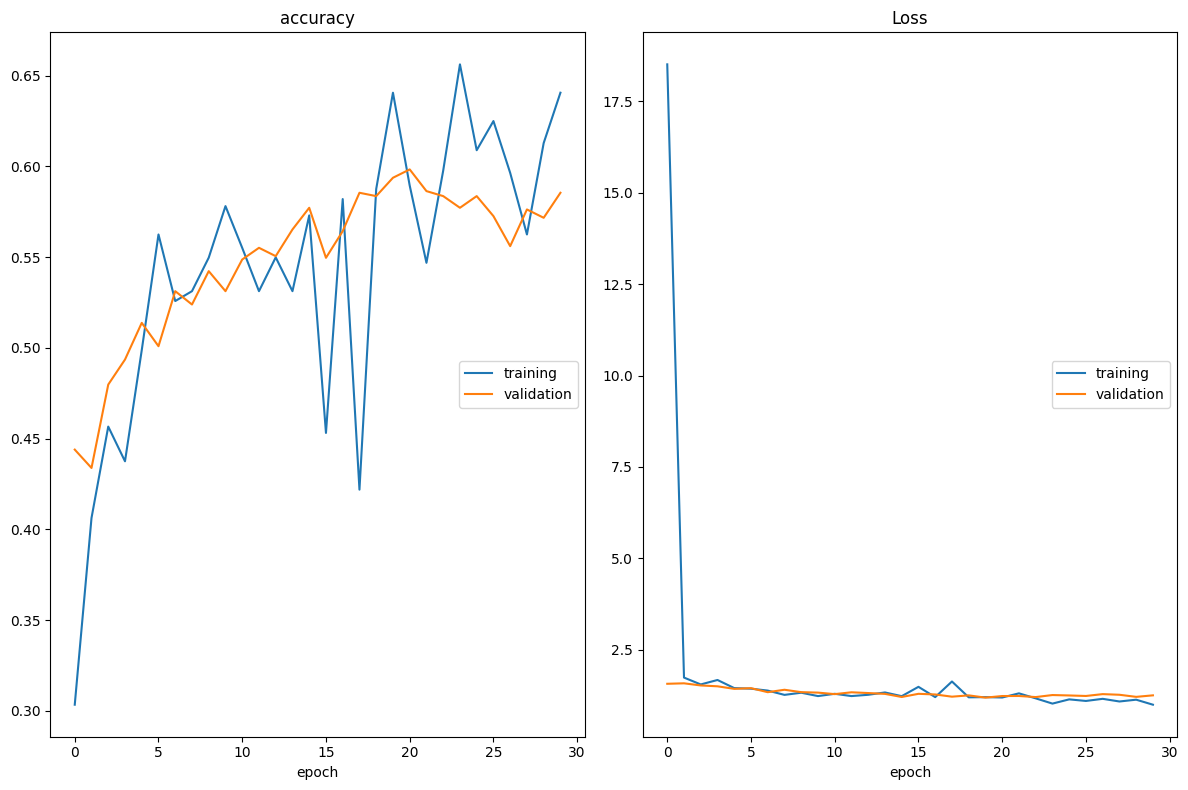

accuracy
	training         	 (min:    0.303, max:    0.656, cur:    0.641)
	validation       	 (min:    0.434, max:    0.598, cur:    0.585)
Loss
	training         	 (min:    0.994, max:   18.514, cur:    0.994)
	validation       	 (min:    1.188, max:    1.579, cur:    1.250)
99/99 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.6406 - loss: 0.9941 - val_accuracy: 0.5855 - val_loss: 1.2501
CPU times: user 38min 12s, sys: 1min 52s, total: 40min 4s
Wall time: 47min 45s


In [ ]:
%%time

vgg_history = vgg_model.fit(traingen,
                            batch_size=BATCH_SIZE,
                            epochs=n_epochs,
                            validation_data=validgen,
                            steps_per_epoch=n_steps,
                            validation_steps=n_val_steps,
                            callbacks=[tl_checkpoint_1, early_stop, plot_loss_1],
                            verbose=1)

ps. Ho runnato con T4 GPU

In [ ]:
# Generate predictions
vgg_model.load_weights('tl_model_v1.weights.best.keras') # initialize the best trained weights

true_classes = testgen.classes
class_indices = traingen.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

vgg_preds = vgg_model.predict(testgen)
vgg_pred_classes = np.argmax(vgg_preds, axis=1)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step


In [ ]:
from sklearn.metrics import accuracy_score

vgg_acc = accuracy_score(true_classes, vgg_pred_classes)
print("VGG16 Model Accuracy without Fine-Tuning: {:.2f}%".format(vgg_acc * 100))

VGG16 Model Accuracy without Fine-Tuning: 71.92%


## Utilizzo di livelli preaddestrati per il Fine-Tuning
In questo approccio, utilizziamo una strategia chiamata Fine-Tuning . L'obiettivo del fine-tuning è consentire a una parte dei livelli pre-addestrati di riaddestrarsi.
Il fine-tuning di un modello pre-addestrato comporta:

1. Avvio di una nuova porzione "superiore" del modello (ovvero, livelli fully connected e di output)
2. Congelamento degli strati convoluzionali pre-addestrati
3. Sblocco degli ultimi livelli di addestramento pre-addestrati.

I layer pre-addestrati e congelati eseguiranno la convoluzione delle feature visive come di consueto. I layer pre-addestrati non congelati (ovvero quelli "addestrabili") saranno addestrati sul nostro dataset personalizzato e aggiornati in base alle previsioni dei livelli Fully Connected.

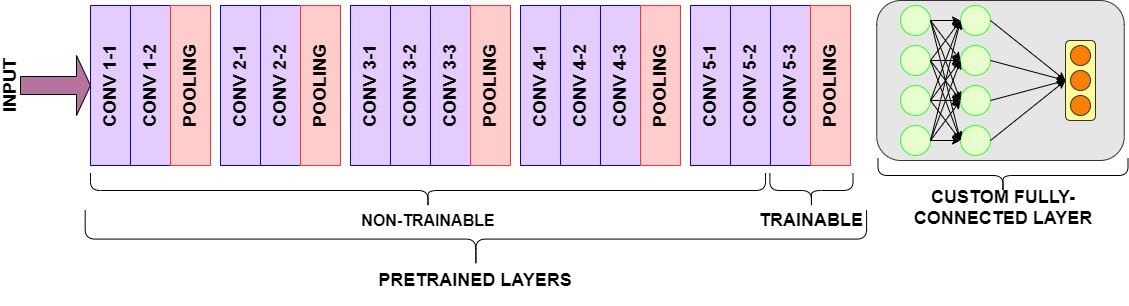

Ricompiliamo il modello, ma consentiamo la backpropagation per aggiornare **gli ultimi due livelli pre-addestrati**.

In [ ]:
# Reset our image data generators
traingen.reset()
validgen.reset()
testgen.reset()

# Use a smaller learning rate
optim_2 = Adam(learning_rate=0.0001)

# Re-compile the model, this time leaving the last 2 layers unfrozen for Fine-Tuning
vgg_model_ft = create_model(input_shape, n_classes, optim_2, fine_tune=2)

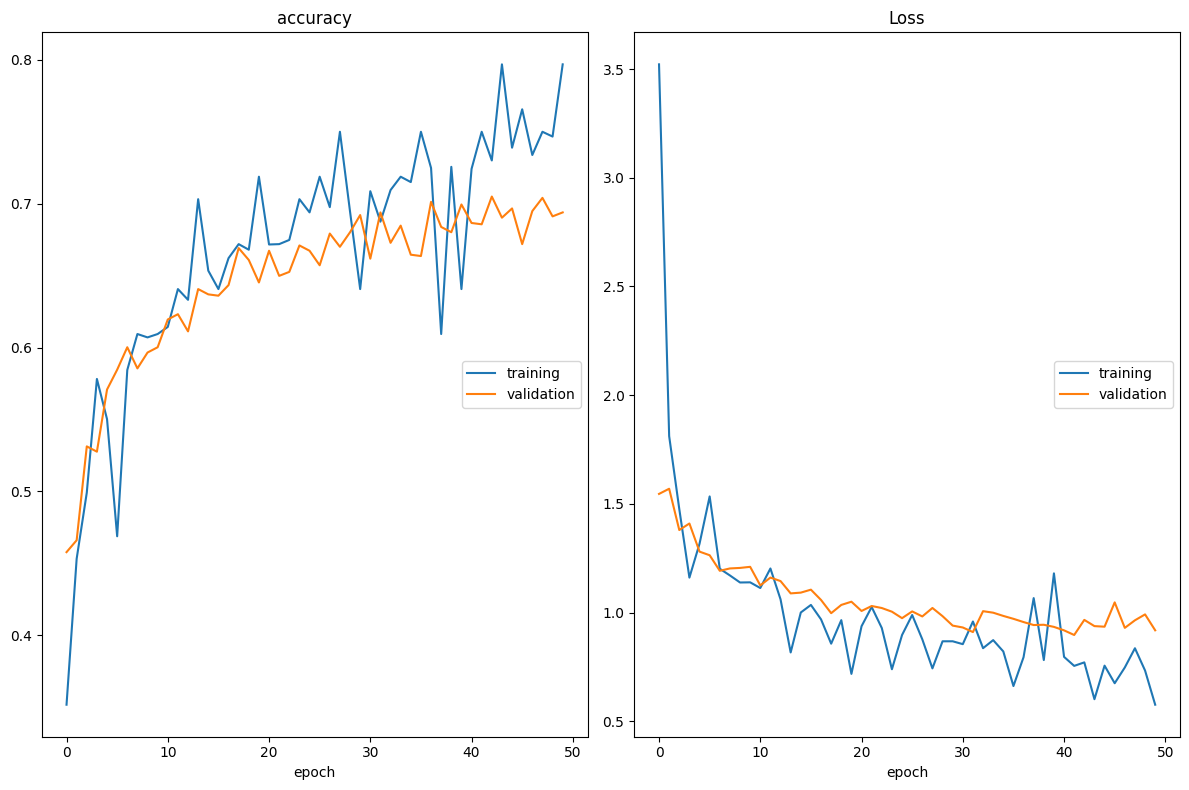

accuracy
	training         	 (min:    0.352, max:    0.797, cur:    0.797)
	validation       	 (min:    0.458, max:    0.705, cur:    0.694)
Loss
	training         	 (min:    0.576, max:    3.522, cur:    0.576)
	validation       	 (min:    0.897, max:    1.570, cur:    0.918)
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.7969 - loss: 0.5761 - val_accuracy: 0.6939 - val_loss: 0.9183
CPU times: user 1h 3min 21s, sys: 2min 38s, total: 1h 5min 59s
Wall time: 1h 5min 55s


In [ ]:
%%time

plot_loss_2 = PlotLossesCallback()

# Retrain model with fine-tuning
vgg_ft_history = vgg_model_ft.fit(traingen,
                                  batch_size=BATCH_SIZE,
                                  epochs=n_epochs,
                                  validation_data=validgen,
                                  steps_per_epoch=n_steps,
                                  validation_steps=n_val_steps,
                                  callbacks=[tl_checkpoint_1, early_stop, plot_loss_2],
                                  verbose=1)

In [ ]:
# Generate predictions
vgg_model_ft.load_weights('tl_model_v1.weights.best.keras') # initialize the best trained weights

vgg_preds_ft = vgg_model_ft.predict(testgen)
vgg_pred_classes_ft = np.argmax(vgg_preds_ft, axis=1)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step


In [ ]:
vgg_acc_ft = accuracy_score(true_classes, vgg_pred_classes_ft)
print("VGG16 Model Accuracy with Fine-Tuning: {:.2f}%".format(vgg_acc_ft * 100))

VGG16 Model Accuracy with Fine-Tuning: 79.72%


Siamo già migliorati!

#Image classification con ResNet

### Importiamo il dataset

In [ ]:
from keras.datasets import cifar10
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Classi Cifrar-10:
1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck






classe: [2]


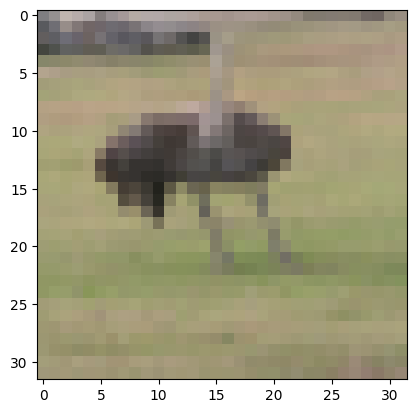

In [ ]:
plt.imshow(X_train[42])
print(f'classe: {Y_train[42]}')

### Pre-processing data

In [ ]:

X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255.0
X_test /= 255.0

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train,stratify=Y_train, test_size = 0.2,shuffle = True)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoder.fit(Y_train)
Y_train = encoder.transform(Y_train).toarray()
Y_test = encoder.transform(Y_test).toarray()
Y_val =  encoder.transform(Y_val).toarray()

In [ ]:
import tensorflow as tf
img_gen = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.05,
                             height_shift_range=0.05,horizontal_flip=True
)
img_gen.fit(X_train)

### Iperparametri

In [ ]:
learningrate=1e-3
momentum=0.8
batch_size=256
epochs=20

# ResNet-50 (Residual Network)

**ResNet**  è un'architettura proposta da He et al. nel 2015, che ha rivoluzionato il deep learning introducendo i residual blocks. Questi blocchi permettono di allenare reti molto profonde (oltre 100 layer) risolvendo il problema del vanishing gradient.

Normalmente, in una rete, ogni layer cerca di imparare una mappatura complessa tra **input** e **output**. Tuttavia, quando la rete è molto profonda, diventa difficile ottimizzare questa mappatura perché i gradienti tendono a diminuire drasticamente, rendendo l'apprendimento inefficace.

Il **residual block** affronta questo problema introducendo una scorciatoia, nota come skip connection, che permette all'input originale di bypassare i layer intermedi e arrivare direttamente all'output.

# Residual Block

![Residual-Block](https://drive.google.com/uc?id=1RsQPFg_jGJoPi9ZJmh9yTimbyyCf_Om_)


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

def create_resnet50_model(input_shape=(32, 32, 3), num_classes=10):

    # Base ResNet50 pre-addestrata su ImageNet
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Costruzione del classificatore
    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs)  # Uso del modello base senza addestramento
    x = layers.GlobalAveragePooling2D()(x)  # Pooling globale, alternativa a Flatten()
    x = layers.Dense(256, activation='relu')(x)  # Fully connected
    x = layers.Dropout(0.5)(x)  # Dropout per regolarizzazione
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # Layer di output

    # Modello completo
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import plot_model

# Carica il modello ResNet50 preaddestrato
model = create_resnet50_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
import keras
model.build(input_shape = (None,32,32,3))
#use categorical_crossentropy since the label is one-hot encoded
model.compile(optimizer = keras.optimizers.SGD(learning_rate=learningrate, momentum=momentum),loss='categorical_crossentropy', metrics=["accuracy"])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 1, 1, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 24,061,706 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
try:
    model.load_weights(save_path + '/pesi_resnet_v1.weights.h5')
    epochs=0
    loaded=True
    print("Pesi modello caricati")
except Exception as e:
    print(f"No weights loaded:\n{e}")
    loaded=False

No weights loaded:
[Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/Colab_Images/Intro_AI_24-25//pesi_resnet_v1.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


In [ ]:
history = model.fit(img_gen.flow(X_train,Y_train,batch_size = batch_size),
                    batch_size = batch_size,
                    epochs=epochs,
                    validation_data=(X_val, Y_val))

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 103s 376ms/step - accuracy: 0.1474 - loss: 3.0913 - val_accuracy: 0.1000 - val_loss: 47.5910
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 181ms/step - accuracy: 0.3173 - loss: 1.9405 - val_accuracy: 0.1000 - val_loss: 21.7151
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.4802 - loss: 1.5258 - val_accuracy: 0.1076 - val_loss: 11.0168
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 179ms/step - accuracy: 0.5607 - loss: 1.2855 - val_accuracy: 0.1446 - val_loss: 2.9932
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 184ms/step - accuracy: 0.6221 - loss: 1.1183 - val_accuracy: 0.3143 - val_loss: 2.1615
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.6526 - loss: 1.0133 - val_accuracy: 0.5416 - val_loss: 1.3196
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.6814 - loss: 0.9470 - val_accuracy: 0.6934 - val_loss: 0.8953
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 178ms/step - accuracy: 0.7098 - loss: 0.8663 -

In [ ]:
model.save_weights('./pesi_resnet.weights.h5')

### Training curves

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


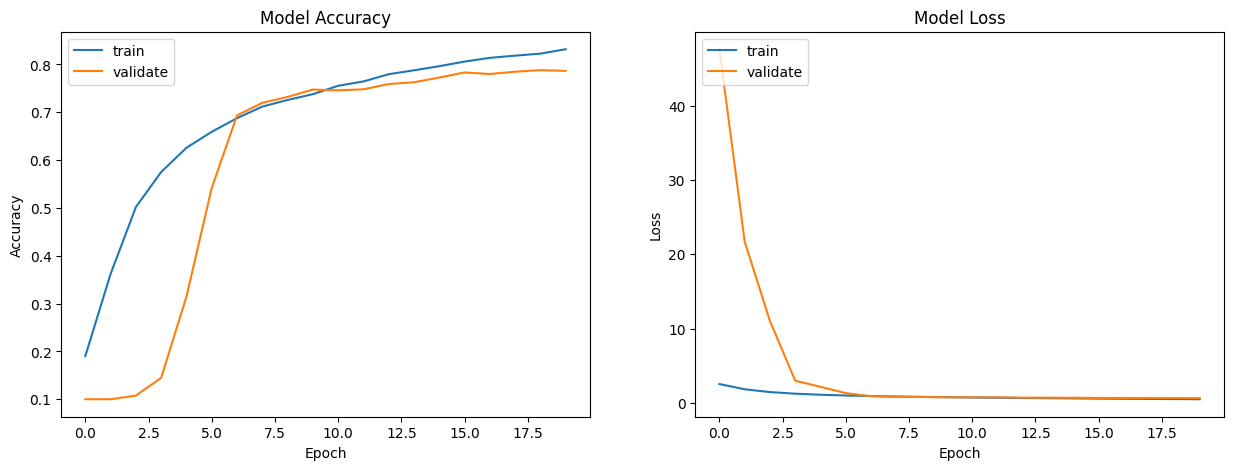

In [ ]:
def plotmodelhistory(history):
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    # summarize history for accuracy
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')

    axs[0].legend(['train', 'validate'], loc='upper left')
    # summarize history for loss
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['train', 'validate'], loc='upper left')
    plt.show()

if not loaded:
  # list all data in history
  print(history.history.keys())
  plotmodelhistory(history)

In [ ]:

ModelLoss, ModelAccuracy = model.evaluate(X_test, Y_test)

print('Model Loss is {}'.format(ModelLoss))
print('Model Accuracy is {}'.format(ModelAccuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7807 - loss: 0.6805
Model Loss is 0.6763579845428467
Model Accuracy is 0.7828999757766724


link all'esempio completo https://www.kaggle.com/code/songrise/implementing-resnet-18-using-keras/notebook

##UpSampling layers (Decoders)


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import UpSampling2D

# Definizione dell'input
input_data = np.array([[[1, 2],
                        [3, 4]]], dtype=np.float32)

# Reshape dell'input aggiungo channels e batch size
input_data = np.reshape(input_data, (1, 2, 2, 1))

# Creazione del modello con UpSampling2D
model_upsampling = Sequential()
model_upsampling.add(UpSampling2D(size=(2, 2), interpolation="nearest"))
#options are: "nearest" (default), "area", "bicubic", "bilinear", "gaussian", "lanczos3", "lanczos5", "mitchellcubic"
model_upsampling.build(input_data.shape)

model_upsampling.summary()

# Applicazione del modello all'input
output_upsampling = model_upsampling.predict(input_data)

# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampare i risultati
print("\nRisultato con UpSampling:")
print(output_upsampling.squeeze())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)         │ (1, 4, 4, 1)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Input:
[[1. 2.]
 [3. 4.]]

Risultato con UpSampling:
[[1. 1. 2. 2.]
 [1. 1. 2. 2.]
 [3. 3. 4. 4.]
 [3. 3. 4. 4.]]


Questo layer tuttavia non apprende nulla per questo è tipicamente usato fra i layer convoluzionali.



##Conv2DTranspose layer (Decoders)

[Alcuni esempi qui](https://calvinfeng.gitbook.io/machine-learning-notebook/supervised-learning/convolutional-neural-network/transpose_convolution_operation)

![Conv2DTranspose](https://drive.google.com/uc?id=1zkPpDEAWzN-jlyiQRzGNBD-s-XtkYL0J )


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2DTranspose

# Definizione dell'input
input_data = np.array([[[1, 2],
                        [3, 4]]], dtype=np.float32)

# Reshape dell'input per adattarlo al formato richiesto dai modelli
input_data = np.reshape(input_data, (1, 2, 2, 1))

# Creazione del modello con Conv2DTranspose
model_transpose_conv = Sequential()
model_transpose_conv.add(Conv2DTranspose(filters=1, kernel_size=(3, 3), strides=(2, 2), padding='same', input_shape=(2, 2, 1)))

# Compilazione del modello
model_transpose_conv.compile(optimizer='adam', loss='mean_squared_error')

# Stampa dell'input
print("Input:")
print(input_data.squeeze())

# Stampa del modello
model_transpose_conv.summary()

# Applicazione del modello all'input
output_transpose_conv = model_transpose_conv.predict(input_data)

# Stampare i risultati
print("\nRisultato con Transpose Convolution:")
print(output_transpose_conv.squeeze())


Input:
[[1. 2.]
 [3. 4.]]


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_transpose (Conv2DTranspose)   │ (None, 4, 4, 1)             │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step

Risultato con Transpose Convolution:
[[-0.128156    0.4119221  -0.29042274  0.8238442 ]
 [-0.25688848 -0.28651813 -0.73148966 -0.57303625]
 [-0.33742166  1.7879149  -0.85273147  2.7519855 ]
 [-0.7706654  -0.8595544  -1.6806921  -1.1460725 ]]


## Autoencoder in breve
Un Autoencoder (AE) è un tipo di rete neurale che impara a comprimere i dati (codificarli) in una rappresentazione più piccola e poi a ricostruirli (decodificarli) nell'input originale.

Non è supervisionato perché non necessita di output etichettati: l'input stesso è il target.

👉 In breve:

**Input → Encoder → Spazio latente → Decoder → Output (≈ Input)**

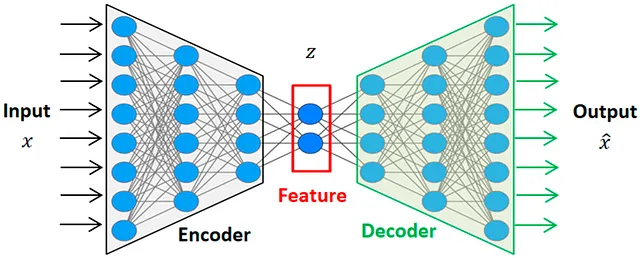


L'encoder mappa i dati di input xxx in una rappresentazione compressa (chiamata spazio latente o collo di bottiglia ).
Consideratela come una riduzione della dimensionalità (simile alla PCA, ma non lineare).
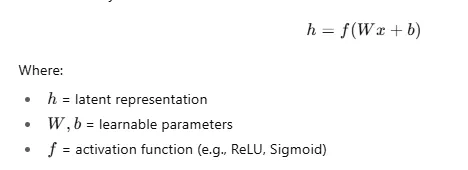

Lo spazio latente rappresenta la forma compressa dell'input.
Cattura le feature più importanti .
La dimensione di questo livello è solitamente molto più piccola della dimensione di input.

Il decoder prende lo spazio latente hhh e prova a ricostruire l'input originale .
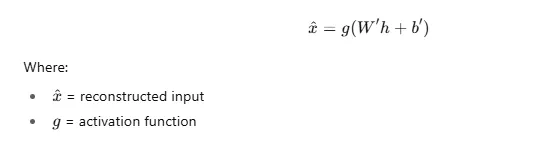

Obiettivo: ridurre al minimo l'errore di ricostruzione, tra le loss funcion usate ricordiamo la Mean Squared Error e la Binary Cross Entropy

Ambiti di applicazione:
- Riduzione della dimensionalità
- Generazione di immagini
- Clustering
- Apprendimento di rappresentazioni semantiche.
- Anomaly detection
- Feature Extraction
- Denoising, riduzione rumore da immagini/audio
- Deblurring

⏱️ Vantaggi
* Apprende rappresentazioni significative.
* Funziona senza dati etichettati.
* Utile per il rilevamento di anomalie e per attività generative.

⚠️ Limitazioni
* Rischio di overfitting (il modello memorizza solo anziché apprendere).
* Può apprendere la mappatura di identità banale se non è vincolato.
* La qualità della ricostruzione potrebbe essere scarsa rispetto ai moderni modelli generativi (GAN, etc).

In [ ]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from keras.models import Model

def autoencoder(input_size=(28, 28, 1)):

    # Input Layer
    inputs = Input(shape=input_size)

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs=inputs, outputs=decoded)
    return model

# Modello dell'autoencoder
model = autoencoder()
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 7, 7, 64)          3692

#Image segmentation

Assegna una "classe" ad ogni pixel dell'immagine.

Con questo approccio, ad esempio puoi:
- sapere la shape dell'oggetto contenuto nell'immagine.
- se un pixel appartiene all'oggetto.
- Estrarre informazioni a livello di pixel.

I task di image segmentation trovano applicazione nelle immagini provenienti dalla guida autonoma, imagini mediche o dei satelliti..

![Image Segmentation](https://drive.google.com/uc?id=1xO189Tlv8GbE86sncajEn6LmkE3NTu6l )


## Dataset


Questo esempio usa il **Dataset Oxford-IIIT Pet** (Parkhi et al, 2012)
Il dataset possiede immagini di 37 animali domestisci (cani e gatti) e ci sono circa 200 immagini per tipo di animale.

Per ogni immagine ci sono delle ground truth:
- label del tipo di animale domestico
- una maschera pixel-wise dove ogni pixel può assumere i valori di:
  *   1 se il pixel appartiene all'animale.
  *   2 se il pixel è del bordo
  *   3 se il pixel è background.


In [ ]:
!pip install keras_cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 46.4 MB/s eta 0:00:00


Lanciamo il comando per installare keras_cv e poi importiamo le librerie.

In [ ]:
import random
import keras
import keras_cv
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from matplotlib import pyplot as plt

Iperparametri

In [ ]:
# Image Config
HEIGHT = 24
WIDTH = 24
NUM_CLASSES = 3
#AUTOTUNE = tf.data.AUTOTUNE #ottimizza in automatico le prestazioni sulla base dell'hw

# Training Config
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3

**Download del dataset.**

Scarichiamo il dataset Oxford-IIT Pet con il modulo TFDS (tensorflow-datasets)

Combiniamo training e test set insieme e poi li splittiamo in 80% training e 20% test. Nello splitting originale, hanno circa la stessa dimensione. Useremo lo splitting del 20% sia come validation e che testing set.


In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!
!gunzip images.tar.gz
!gunzip annotations.tar.gz
!
!tar -xf images.tar
!tar -xf annotations.tar



--2024-12-02 10:06:18--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2024-12-02 10:06:19--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  17.1MB/s    in 32s     

2024-12-02 10:06:52 (23.4 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2024-12-02 10:06:52--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

Data preprocessing

Link alla documentazione: https://www.tensorflow.org/datasets/catalog/oxford_iiit_pet

In [ ]:
import os

input_dir = "images/"
target_dir = "annotations/trimaps/"
img_size = (160, 160)
num_classes = 3
batch_size = 32

input_img_paths = sorted(
    [
        os.path.join(input_dir, fname)
        for fname in os.listdir(input_dir)
        if fname.endswith(".jpg")
    ]
)
target_img_paths = sorted(
    [
        os.path.join(target_dir, fname)
        for fname in os.listdir(target_dir)
        if fname.endswith(".png") and not fname.startswith(".")
    ]
)

print("Number of samples:", len(input_img_paths))

for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
    print(input_path, "|", target_path)

Number of samples: 7390
images/Abyssinian_1.jpg | annotations/trimaps/Abyssinian_1.png
images/Abyssinian_10.jpg | annotations/trimaps/Abyssinian_10.png
images/Abyssinian_100.jpg | annotations/trimaps/Abyssinian_100.png
images/Abyssinian_101.jpg | annotations/trimaps/Abyssinian_101.png
images/Abyssinian_102.jpg | annotations/trimaps/Abyssinian_102.png
images/Abyssinian_103.jpg | annotations/trimaps/Abyssinian_103.png
images/Abyssinian_104.jpg | annotations/trimaps/Abyssinian_104.png
images/Abyssinian_105.jpg | annotations/trimaps/Abyssinian_105.png
images/Abyssinian_106.jpg | annotations/trimaps/Abyssinian_106.png
images/Abyssinian_107.jpg | annotations/trimaps/Abyssinian_107.png


In [ ]:
import random


# Define the split ratio (e.g., 80% train, 20% test)
split_ratio = 0.8

# Calculate the split index
split_index = int(len(input_img_paths) * split_ratio)

# Create a list of indices for all samples
indices = list(range(len(input_img_paths)))

# Shuffle the indices randomly
random.shuffle(indices) # mescola gli indici perchè noi a ogni immagine dobbiamo recuperare anche la
#maschera associata

# Split the indices into training and testing sets
train_indices = indices[:split_index]
test_indices = indices[split_index:]

# Create the training and testing datasets using the indices
x_train = [input_img_paths[i] for i in train_indices]
y_train = [target_img_paths[i] for i in train_indices]
x_test = [input_img_paths[i] for i in test_indices]
y_test = [target_img_paths[i] for i in test_indices]

print("Number of training samples:", len(x_train))
print("Number of testing samples:", len(x_test))

Number of training samples: 5912
Number of testing samples: 1478


Visualizziamo alcune immagini

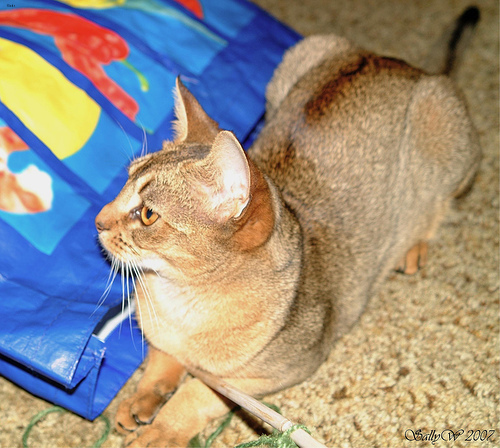

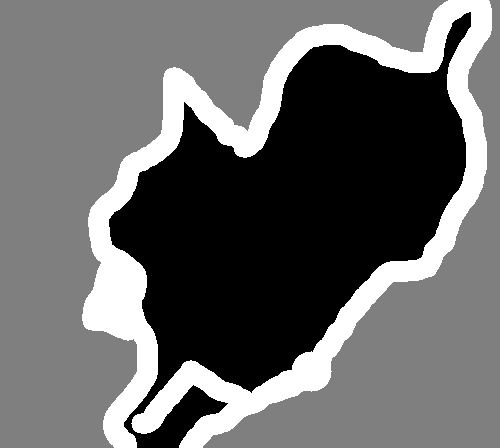

In [ ]:
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps

# Display input image #7
display(Image(filename=input_img_paths[9]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = ImageOps.autocontrast(load_img(target_img_paths[9]))
display(img)

In [ ]:
import keras
import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io


def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        #input_img = tf_image.convert_image_dtype(input_img, "float32")

        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

In [ ]:
train_dataset=get_dataset(BATCH_SIZE, img_size, x_train, y_train)
val_dataset=get_dataset(BATCH_SIZE, img_size, x_test, y_test)

## Visualizziamo qualche immagine nel dataset

Shape immagini: (64, 160, 160, 3), Dtype: <dtype: 'float32'>
Shape maschere: (64, 160, 160, 1), Dtype: <dtype: 'uint8'>


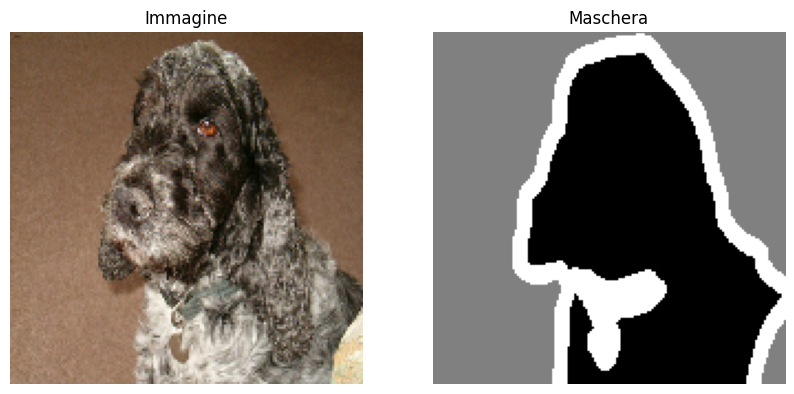

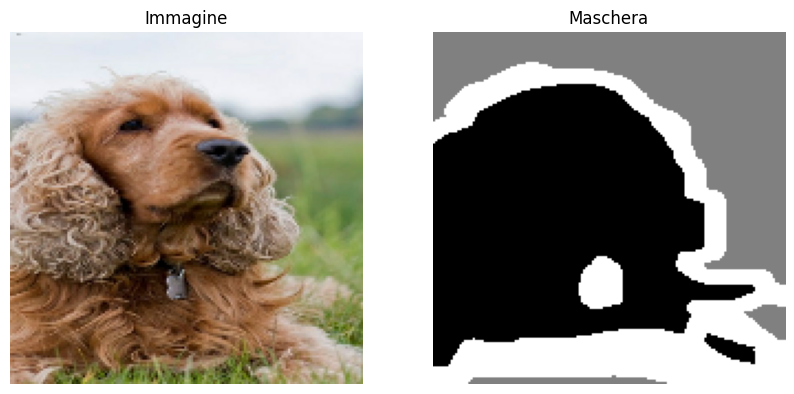

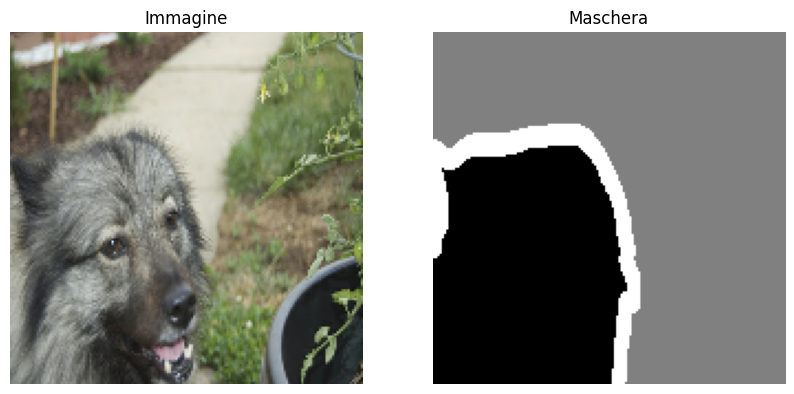

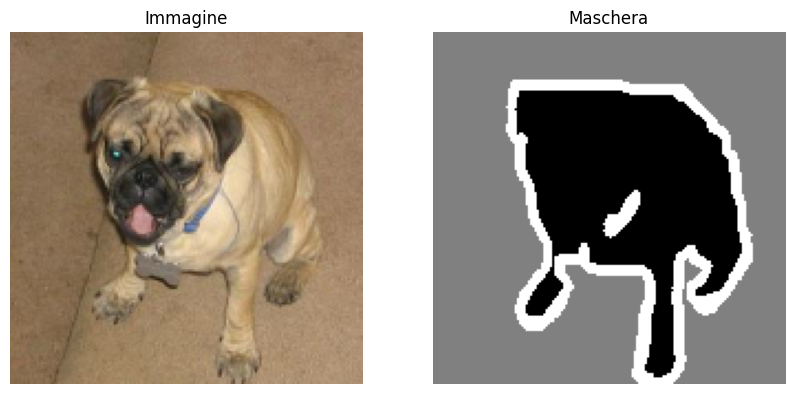

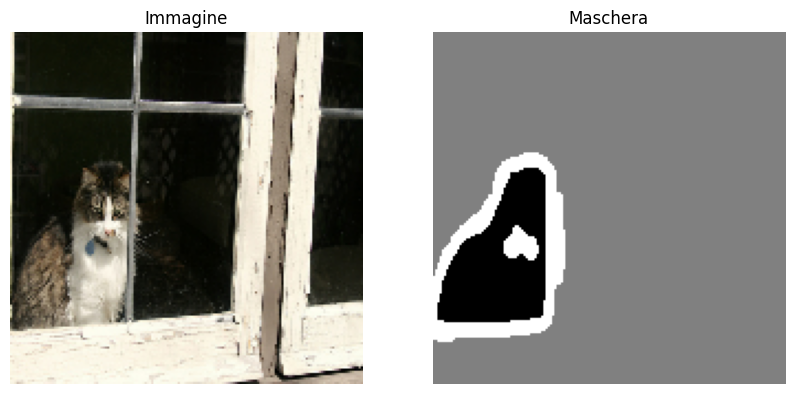

In [ ]:
import matplotlib.pyplot as plt
for batch in train_dataset.take(1):  # Itera su un singolo batch
    images, masks = batch  # Scompone il batch in immagini e maschere

    print(f"Shape immagini: {images.shape}, Dtype: {images.dtype}")
    print(f"Shape maschere: {masks.shape}, Dtype: {masks.dtype}")

    # Visualizza le prime 5 immagini e relative maschere
    for i in range(5):
        plt.figure(figsize=(10, 5))

        # Immagine
        plt.subplot(1, 2, 1)
        plt.imshow((images[i].numpy()).astype("uint8"))
        plt.title("Immagine")
        plt.axis("off")

        # Maschera
        plt.subplot(1, 2, 2)
        plt.imshow(masks[i].numpy().squeeze(), cmap="gray")  # Rimuovi dimensioni superflue
        plt.title("Maschera")
        plt.axis("off")

        plt.show()

Creiamo una callback che mostra lo stato di avanzamento del training alla fine di ogni epoch_interval.

Chiamiamo test-set un batch del trainig set su cui misurare i progressi nella callback.

In [ ]:
# Taking a batch of test inputs to measure model's progress.
test_images, test_masks = next(iter(val_dataset))

class DisplayCallback(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            pred_masks = self.model.predict(test_images)
            pred_masks = tf.math.argmax(pred_masks, axis=-1)
            pred_masks = pred_masks[..., tf.newaxis] #aggiunge una nuova dimensione alla fine di pred_masks,
            # "..." è l'operatore di slicing ellittico, rappresenta tutte le dim non specificate.

            # Randomly select an image from the test batch
            random_index = random.randint(0, BATCH_SIZE - 1)
            random_image = test_images[random_index]
            random_pred_mask = pred_masks[random_index]
            random_true_mask = test_masks[random_index]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))
            ax[0].imshow(random_image.numpy().astype("uint8"))
            ax[0].set_title(f"Image: {epoch:03d}")

            ax[1].imshow(random_true_mask)
            ax[1].set_title(f"Ground Truth Mask: {epoch:03d}")

            ax[2].imshow(random_pred_mask)
            ax[2].set_title(f"Predicted Mask: {epoch:03d}", )

            plt.show()
            plt.close()


callbacks = [DisplayCallback(4)]

# U-Net
La U-Net è un'architettura di rete convoluzionale pensata per la semantic segmentation. È composta da due parti principali:

**Encoder**: Riduce la dimensione spaziale dell'immagine, estraendo feature rilevanti tramite convoluzioni e pooling.

**Decoder**: Ricostruisce la dimensione originale, combinando upsampling e convoluzioni.

Un aspetto chiave della U-Net sono le **skip connections**, che collegano le feature map dell'encoder al decoder, permettendo di preservare dettagli spaziali fondamentali per una segmentazione accurata.

Progettata inizialmente per immagini biomediche, U-Net è oggi usata in molti contesti, come la guida autonoma e l'analisi di immagini satellitari, grazie alla sua capacità di segmentare accuratamente oggetti anche con dataset limitati.

![UNet](https://drive.google.com/uc?id=1UjsHXtPfb4ZeRzICpZJ-xcGZrusmqirv )


In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate

def down_block(inputs, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(inputs)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    pool = MaxPooling2D(pool_size=(2, 2))(conv)
    return conv, pool

def up_block(inputs, skip, filters, kernel_size=(3, 3), padding='same', activation='relu'):
    up = UpSampling2D(size=(2, 2))(inputs)
    concat = Concatenate()([up, skip])
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(concat)
    conv = Conv2D(filters, kernel_size, activation=activation, padding=padding)(conv)
    return conv


def unet(img_size=(256, 256, 1), num_classes=1):
    inputs = Input(shape=img_size + (3,))

    #Down Blocks
    conv1, pool1 = down_block(inputs, 64)
    conv2, pool2 = down_block(pool1, 128)
    conv3, pool3 = down_block(pool2, 256)

    # Bottleneck
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)

    #Up Blocks
    conv5 = up_block(conv4, conv3, 256)
    conv6 = up_block(conv5, conv2, 128)
    conv7 = up_block(conv6, conv1, 64)

    # Add a per-pixel classification layer
    outputs = keras.layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(conv7)

    model = Model(inputs=inputs, outputs=outputs, name="unet")
    return model



Instazia il modello

In [ ]:
# Build model
model = unet(img_size=img_size, num_classes=NUM_CLASSES)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 160, 160, 64)   │          1,792 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 160, 160, 64)   │         36,928 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 80, 80, 64)     │              0 │ conv2d_2[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 80, 80, 128)    │         73,856 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 80, 80, 128)    │        147,584 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 40, 40, 128)    │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 40, 40, 256)    │        295,168 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 40, 40, 256)    │        590,080 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 20, 20, 256)    │              0 │ conv2d_6[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 20, 20, 512)    │      1,180,160 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 20, 20, 512)    │      2,359,808 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_1           │ (None, 40, 40, 512)    │              0 │ conv2d_8[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 40, 40, 768)    │              0 │ up_sampling2d_1[0][0], │
│                           │                        │                │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 40, 40, 256)    │      1,769,728 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 40, 40, 256)    │        590,080 │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_2      

 Total params: 7,784,579 (29.70 MB)

 Trainable params: 7,784,579 (29.70 MB)

 Non-trainable params: 0 (0.00 B)

Compila e allena

No weights loaded:
[Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/Colab_Images/Intro_AI_24-25//pesi_modello_v1.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5515 - loss: 13.6000

2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step


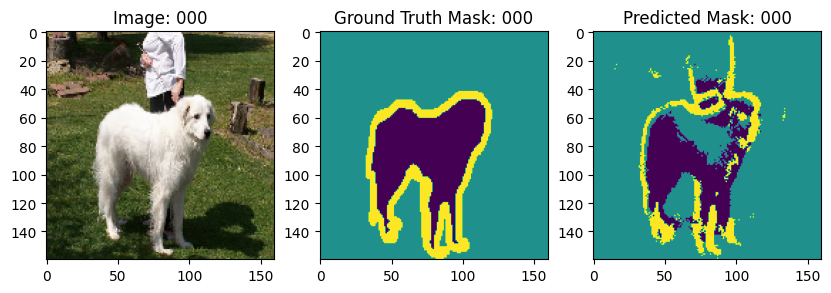

93/93 ━━━━━━━━━━━━━━━━━━━━ 342s 3s/step - accuracy: 0.5524 - loss: 13.4975 - val_accuracy: 0.6944 - val_loss: 0.7407
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7236 - loss: 0.6917 - val_accuracy: 0.7528 - val_loss: 0.6201
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.7641 - loss: 0.5910 - val_accuracy: 0.7699 - val_loss: 0.5744
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7909 - loss: 0.5266 - val_accuracy: 0.8001 - val_loss: 0.5121
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8116 - loss: 0.4788 - val_accuracy: 0.8139 - val_loss: 0.4822
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


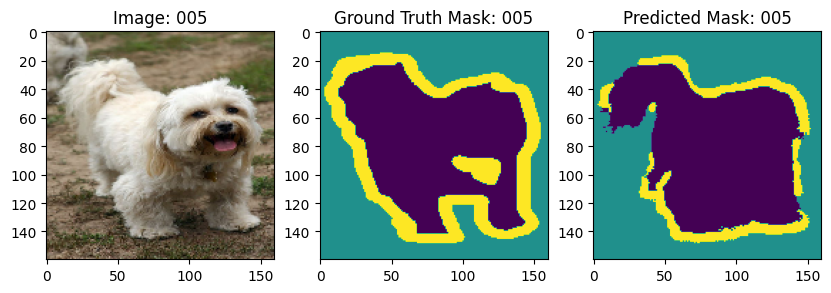

93/93 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.8272 - loss: 0.4418 - val_accuracy: 0.8126 - val_loss: 0.4843
Epoch 7/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8353 - loss: 0.4231 - val_accuracy: 0.8174 - val_loss: 0.4733
Epoch 8/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8454 - loss: 0.3954 - val_accuracy: 0.8293 - val_loss: 0.4426
Epoch 9/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8539 - loss: 0.3757 - val_accuracy: 0.8421 - val_loss: 0.4171
Epoch 10/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.8610 - loss: 0.3583 - val_accuracy: 0.8416 - val_loss: 0.4293


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

try:
    model.load_weights(save_path + '/pesi_modello_v1.weights.h5')
    EPOCHS=0
    print("Pesi modello caricati")
except Exception as e:
    print(f"No weights loaded:\n{e}")


# Train the model, doing validation at the end of each epoch.
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Sovrascrivo i pesi.

In [ ]:
model.save_weights(save_path + '/pesi_modello.weights.h5')

Esempio di predizione su alcune immagini dopo che la rete è stata allenata.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


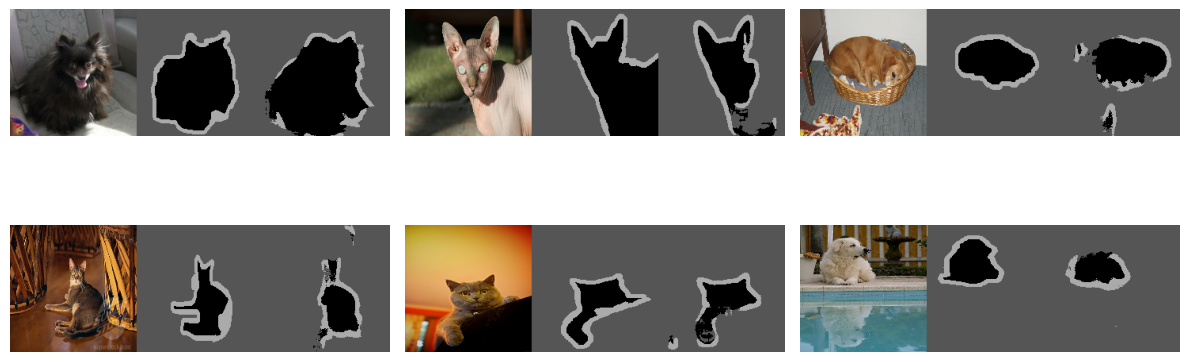

In [ ]:
model.load_weights(save_path + '/pesi_modello.weights.h5')

pred_masks = model.predict(test_images)
pred_masks = tf.math.argmax(pred_masks, axis=-1)[..., None]

keras_cv.visualization.plot_segmentation_mask_gallery(
    test_images.numpy().astype("uint8"),
    value_range=(0, 255),
    num_classes=3,
    y_true=test_masks,
    y_pred=pred_masks,
    scale=4,
    rows=2,
    cols=3,
)

Esempio completo a questo link:
https://keras.io/examples/vision/oxford_pets_image_segmentation/#prediction-with-trained-model

